# Signet Implementation

In [ ]:
!pip install kagglehub==1.0.0

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.1/40.1 kB 2.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 70.6/70.6 kB 2.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 160.5/160.5 kB 8.6 MB/s eta 0:00:00
  Attempting uninstall: kagglehub
    Found existing installation: kagglehub 0.3.13
    Uninstalling kagglehub-0.3.13:
      Successfully uninstalled kagglehub-0.3.13


In [ ]:
import kagglehub
path = kagglehub.dataset_download("akashgundu/signature-verification-dataset")
data_dir = f"{path}/extract"

In [ ]:
data_dir

'/root/.cache/kagglehub/datasets/akashgundu/signature-verification-dataset/versions/1/extract'

# creating all pairs possible

In [ ]:
import os
import random
import pandas as pd
import numpy as np
from itertools import combinations

#output_csv = "/content/drive/My Drive/signature_dataset/pairs.csv"

pairs = []

# Get all genuine folders (exclude _forg)
ids = sorted([f for f in os.listdir(data_dir) if "_forg" not in f])

for id_name in ids:
    genuine_dir = os.path.join(data_dir, id_name)
    forged_dir = os.path.join(data_dir, id_name + "_forg")

    if not os.path.exists(forged_dir):
        continue

    # Filter strictly for jpg files
    genuine_images = sorted([
        f for f in os.listdir(genuine_dir)
        if f.lower().endswith(".jpg")
    ])

    forged_images = sorted([
        f for f in os.listdir(forged_dir)
        if f.lower().endswith(".jpg")
    ])

    # Genuine-Genuine pairs (label 0)
    for img1, img2 in combinations(genuine_images, 2):
        pairs.append([
            f"{id_name}/{img1}",
            f"{id_name}/{img2}",
            0
        ])

    # Genuine-Forged pairs (label 1)
    for g_img in genuine_images:
        for f_img in forged_images:
            pairs.append([
                f"{id_name}/{g_img}",
                f"{id_name}_forg/{f_img}",
                1
            ])

# Save CSV
df = pd.DataFrame(pairs, columns=["image1", "image2", "label"])
#df.to_csv(output_csv, index=False)

#print("pairs.csv created successfully!")
print("Total pairs:", len(df))

Total pairs: 113647


# All Pairs

In [ ]:
df

,image1,image2,label
0,001/1-001_01.jpg,001/1-001_010.jpg,0
1,001/1-001_01.jpg,001/1-001_02.jpg,0
2,001/1-001_01.jpg,001/1-001_03.jpg,0
3,001/1-001_01.jpg,001/1-001_04.jpg,0
4,001/1-001_01.jpg,001/1-001_05.jpg,0
...,...,...,...
113642,686/94.jpg,686_forg/55.jpg,1
113643,686/94.jpg,686_forg/65.jpg,1
113644,686/94.jpg,686_forg/75.jpg,1
113645,686/94.jpg,686_forg/85.jpg,1


#Difference between pairs

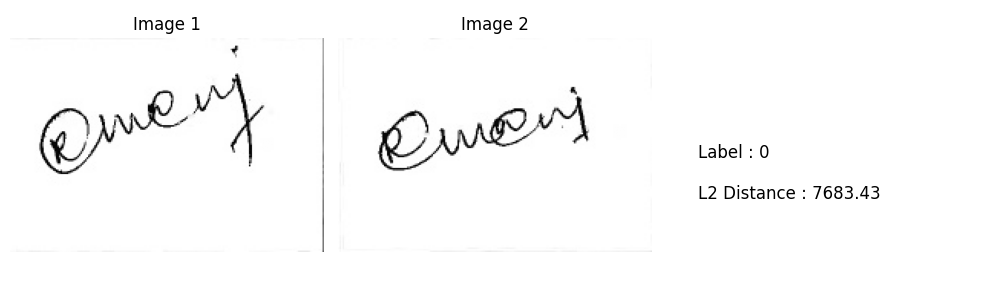

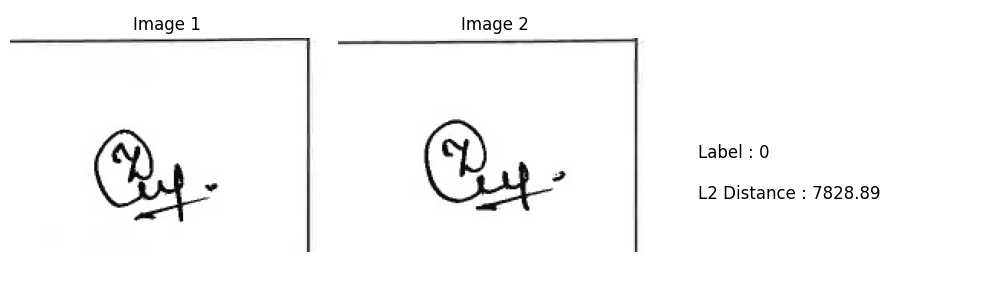

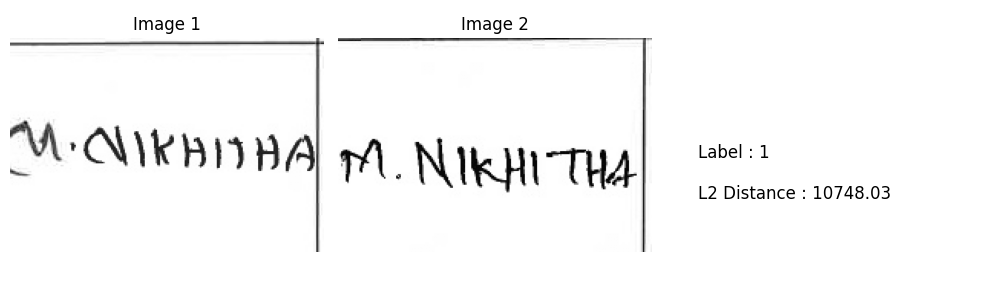

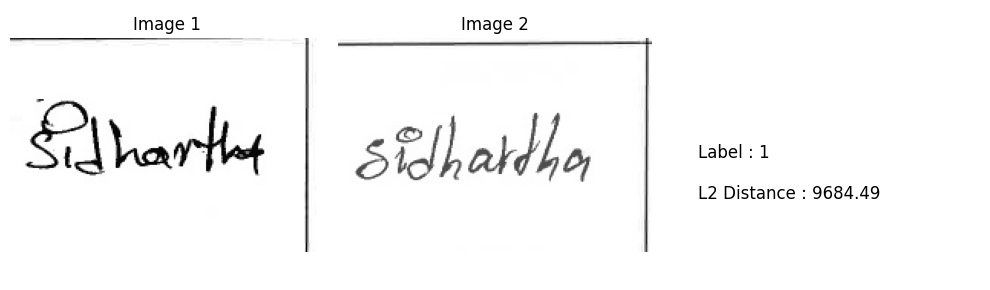

In [ ]:
import matplotlib.pyplot as plt
from PIL import Image

rows_to_view = [10, 2500, 1000, 12000]

for idx in rows_to_view:

    row = df.iloc[idx]

    img1_path = os.path.join(data_dir, row["image1"])
    img2_path = os.path.join(data_dir, row["image2"])
    label = row["label"]

    # Load grayscale images
    img1 = Image.open(img1_path).convert("L")
    img2 = Image.open(img2_path).convert("L")

    img1_np = np.array(img1, dtype=np.float32)
    img2_np = np.array(img2, dtype=np.float32)

    # Resize if needed
    if img1_np.shape != img2_np.shape:
        img2 = img2.resize(img1.size)
        img2_np = np.array(img2, dtype=np.float32)

    # L2 distance
    l2_distance = np.sqrt(np.sum((img1_np - img2_np) ** 2))

    # Plot layout
    fig, ax = plt.subplots(1,3, figsize=(10,3))

    ax[0].imshow(img1_np, cmap='gray')
    ax[0].set_title("Image 1")
    ax[0].axis("off")

    ax[1].imshow(img2_np, cmap='gray')
    ax[1].set_title("Image 2")
    ax[1].axis("off")

    # Right side text panel
    ax[2].axis("off")
    ax[2].text(0.1,0.45,f"Label : {label}", fontsize=12)
    ax[2].text(0.1,0.3,f"L2 Distance : {l2_distance:.2f}", fontsize=12)

    plt.tight_layout()
    plt.show()

In [ ]:
def show_pixel_difference(row_index):

    row = df.iloc[row_index]

    img1_path = os.path.join(data_dir, row["image1"])
    img2_path = os.path.join(data_dir, row["image2"])

    # Load grayscale images
    img1 = Image.open(img1_path).convert("L")
    img2 = Image.open(img2_path).convert("L")

    img1_np = np.array(img1, dtype=np.float32)
    img2_np = np.array(img2, dtype=np.float32)

    # Resize if shapes differ
    if img1_np.shape != img2_np.shape:
        img2 = img2.resize(img1.size)
        img2_np = np.array(img2, dtype=np.float32)

    # Absolute pixel difference
    diff = np.abs(img1_np - img2_np)

    # Plot
    fig, ax = plt.subplots(figsize=(4,4))
    im = ax.imshow(diff, cmap="hot")

    ax.set_title(f"Pixel Difference | Row {row_index} | Label: {row['label']}")
    ax.axis("off")

    # Colorbar below image
    fig.colorbar(im, ax=ax, orientation="horizontal", pad=0.08)

    plt.show()

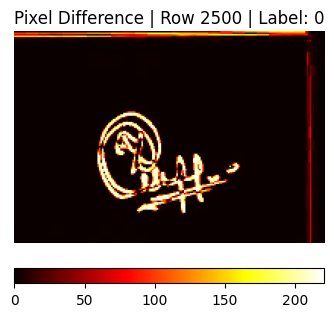

In [ ]:
show_pixel_difference(2500)

# Creating Test, Train and Validation pairs

In [ ]:
from sklearn.model_selection import train_test_split

# 70% train, 30% temp
train_df, temp_df = train_test_split(
    df, test_size=0.3, random_state=42, stratify=df["label"]
)

# Split temp into val (15%) and test (15%)
val_df, test_df = train_test_split(
    temp_df, test_size=0.5, random_state=42, stratify=temp_df["label"]
)

print("Train:", len(train_df))
print("Val:", len(val_df))
print("Test:", len(test_df))

Train: 79552
Val: 17047
Test: 17048


###Imports

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F

from torch.utils.data import Dataset, DataLoader
from PIL import Image, UnidentifiedImageError
import torchvision.transforms as transforms

###Dataset loading

In [ ]:
image_dir = data_dir

transform = transforms.Compose([
    transforms.Resize((155,220)),
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

In [ ]:
class SiameseDataset(Dataset):

    def __init__(self, dataframe, image_dir, transform=None):
        self.df = dataframe.reset_index(drop=True)
        self.image_dir = image_dir
        self.transform = transform

    def __getitem__(self, index):

        img1_rel = self.df.iloc[index, 0]
        img2_rel = self.df.iloc[index, 1]

        img1_path = os.path.join(self.image_dir, img1_rel)
        img2_path = os.path.join(self.image_dir, img2_rel)

        try:
          img1 = Image.open(img1_path).convert("L")
          img2 = Image.open(img2_path).convert("L")
        except UnidentifiedImageError:
          # pick another sample if image is broken
          return self.__getitem__((index + 1) % len(self.df))

        if self.transform:
            img1 = self.transform(img1)
            img2 = self.transform(img2)

        label = torch.tensor(self.df.iloc[index, 2], dtype=torch.float32).unsqueeze(0)

        return img1, img2, label

    def __len__(self):
        return len(self.df)

In [ ]:
train_dataset = SiameseDataset(train_df, image_dir, transform)
val_dataset = SiameseDataset(val_df, image_dir, transform)
test_dataset = SiameseDataset(test_df, image_dir, transform)

In [ ]:
batch_size = 16

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True,num_workers=2,pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False,num_workers=2,pin_memory=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False,num_workers=2,pin_memory=True)

##Siamese

In [ ]:
class SiameseNetwork(nn.Module):

    def __init__(self):
        super().__init__()

        self.features = nn.Sequential(

            # Block 1
            nn.Conv2d(1, 32, 3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),

            # Block 2
            nn.Conv2d(32, 64, 3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2),

            # Block 3
            nn.Conv2d(64, 128, 3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2),

            # Block 4
            nn.Conv2d(128, 256, 3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )

        self.pool = nn.AdaptiveAvgPool2d((1,1))

        self.embedding = nn.Sequential(
            nn.Linear(256,256),
            nn.ReLU(),
            nn.Linear(256,128),
            nn.ReLU()
        )

        self.classifier = nn.Sequential(
            nn.Linear(384,128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128,64),
            nn.ReLU(),
            nn.Linear(64,1)
        )

    def forward_once(self,x):

        x = self.features(x)
        x = self.pool(x)
        x = x.view(x.size(0),-1)

        embedding = self.embedding(x)

        return embedding


    def forward(self,x1,x2):

        e1 = self.forward_once(x1)
        e2 = self.forward_once(x2)

        #diff = torch.abs(e1 - e2)
        x = torch.cat([e1, e2, torch.abs(e1-e2)], dim=1)
        out = self.classifier(x)

        return out

# Model Setup

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = SiameseNetwork().to(device)

criterion = nn.BCEWithLogitsLoss()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=1e-3
)

# Train Function

In [ ]:
def train_one_epoch(loader):

    model.train()
    running_loss = 0

    for img1,img2,label in loader:

        img1 = img1.to(device)
        img2 = img2.to(device)
        label = label.to(device)

        optimizer.zero_grad()

        logits = model(img1,img2)

        loss = criterion(logits,label)

        loss.backward()

        optimizer.step()

        running_loss += loss.item()

    return running_loss/len(loader)

# Validation Function

In [ ]:
def evaluate(loader):

    model.eval()

    total_loss = 0

    with torch.no_grad():

        for img1,img2,label in loader:

            img1 = img1.to(device)
            img2 = img2.to(device)
            label = label.to(device)

            logits = model(img1,img2)

            loss = criterion(logits,label)

            total_loss += loss.item()

    return total_loss/len(loader)

# training and validation

In [ ]:
epochs = 5

for epoch in range(epochs):
    train_loss = train_one_epoch(train_loader)
    val_loss = evaluate(val_loader)
    model_path = f"signet2_model_{epoch+5}.pth"
    torch.save(model.state_dict(), model_path)
    print(f"Epoch {epoch+1}/{epochs} | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f}")

Epoch 1/5 | Train Loss: 0.0564 | Val Loss: 0.1019
Epoch 2/5 | Train Loss: 0.0420 | Val Loss: 0.0530
Epoch 3/5 | Train Loss: 0.0339 | Val Loss: 0.0808
Epoch 4/5 | Train Loss: 0.0285 | Val Loss: 0.1320
Epoch 5/5 | Train Loss: 0.0264 | Val Loss: 0.0618


# Save Model

In [ ]:
model_path = "signet2_model.pth"

torch.save(model.state_dict(), model_path)

print("Model saved at:", model_path)

Model saved at: signet2_model.pth


In [ ]:
model = SiameseNetwork().to(device)

#model.load_state_dict(torch.load("signet2_model_6.pth"))
model.load_state_dict(torch.load("signet2_model_6.pth", map_location="cpu"))

model.eval()

SiameseNetwork(
  (features): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (8): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU()
    (11): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (12): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (13): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=

# Training Loss and Validation Loss Graph

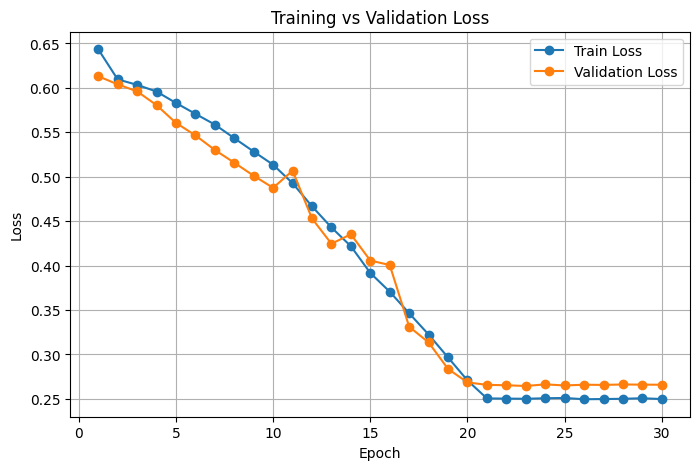

In [ ]:
import matplotlib.pyplot as plt

# Epoch numbers
epochs = list(range(1, 31))

# Training and Validation loss values
train_loss = [
    0.6435, 0.6096, 0.6034, 0.5959, 0.5830,
    0.5708, 0.5587, 0.5434, 0.5283, 0.5135,
    0.4927, 0.4667, 0.4429, 0.4218, 0.3917,
    0.3706, 0.3463, 0.3224, 0.2966, 0.2707,
    0.2505, 0.2503, 0.2501, 0.2507, 0.2510,
    0.2496, 0.2498, 0.2501, 0.2507, 0.2498
]

val_loss = [
    0.6131, 0.6040, 0.5961, 0.5806, 0.5606,
    0.5466, 0.5301, 0.5158, 0.5011, 0.4875,
    0.5068, 0.4530, 0.4246, 0.4352, 0.4057,
    0.4006, 0.3312, 0.3135, 0.2837, 0.2685,
    0.2658, 0.2653, 0.2645, 0.2663, 0.2651,
    0.2659, 0.2657, 0.2662, 0.2660, 0.2659
]

# Plot
plt.figure(figsize=(8,5))
plt.plot(epochs, train_loss, marker='o', label="Train Loss")
plt.plot(epochs, val_loss, marker='o', label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()
plt.grid(True)

plt.show()

# Accuracy

In [ ]:
def test_accuracy(loader, threshold=0.5):

    model.eval()

    correct = 0
    total = 0

    with torch.no_grad():

        for img1,img2,label in loader:

            img1 = img1.to(device)
            img2 = img2.to(device)
            label = label.to(device)

            logits = model(img1,img2)

            probs = torch.sigmoid(logits)

            preds = (probs > threshold).float()

            correct += (preds == label).sum().item()

            total += label.size(0)

    return correct/total

In [ ]:
acc = test_accuracy(test_loader)

print("Test Accuracy:",acc*100)

Test Accuracy: 98.16400750821211


# Threshold Vs Accuracy

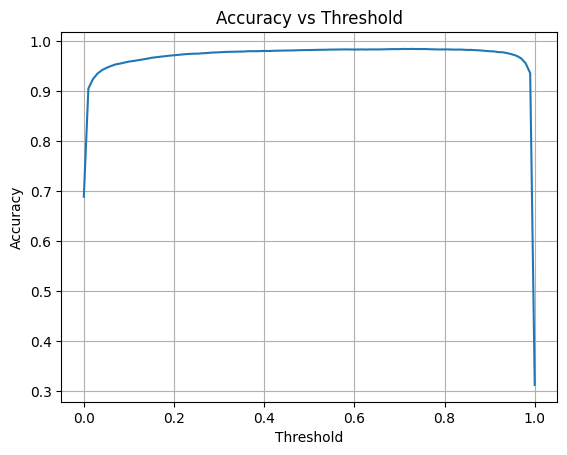

In [ ]:
thresholds = np.linspace(0,1,100)

accuracies = []

for t in thresholds:
    acc = test_accuracy(test_loader, threshold=t)
    accuracies.append(acc)

plt.figure()
plt.plot(thresholds, accuracies)
plt.xlabel("Threshold")
plt.ylabel("Accuracy")
plt.title("Accuracy vs Threshold")
plt.grid(True)
plt.show()

# EER

In [ ]:
from sklearn.metrics import confusion_matrix

thresholds = np.linspace(0,1,100)

far_list = []
frr_list = []

model.eval()

for t in thresholds:

    TP = FP = TN = FN = 0

    with torch.no_grad():

        for img1,img2,label in test_loader:

            img1 = img1.to(device)
            img2 = img2.to(device)
            label = label.to(device)

            logits = model(img1,img2)
            probs = torch.sigmoid(logits)

            preds = (probs > t).float()

            TP += ((preds==1) & (label==1)).sum().item()
            TN += ((preds==0) & (label==0)).sum().item()
            FP += ((preds==1) & (label==0)).sum().item()
            FN += ((preds==0) & (label==1)).sum().item()

    FAR = FP / (FP + TN)
    FRR = FN / (FN + TP)

    far_list.append(FAR)
    frr_list.append(FRR)


In [ ]:
plt.figure()
plt.plot(thresholds, far_list, label="FRR")
plt.plot(thresholds, frr_list, label="FAR")
plt.xlabel("Threshold")
plt.ylabel("Error Rate")
plt.title("FAR vs FRR")
plt.legend()
plt.grid(True)
plt.show()

# Other metrics

In [ ]:
from sklearn.metrics import precision_score, recall_score, f1_score, confusion_matrix, classification_report

In [ ]:
def get_predictions(loader, threshold=0.5):

    model.eval()

    all_labels = []
    all_preds = []

    with torch.no_grad():

        for img1, img2, label in loader:

            img1 = img1.to(device)
            img2 = img2.to(device)

            logits = model(img1, img2)
            probs = torch.sigmoid(logits)

            preds = (probs > threshold).float()

            all_labels.extend(label.cpu().numpy())
            all_preds.extend(preds.cpu().numpy())

    return all_labels, all_preds

In [ ]:
y_true, y_pred = get_predictions(test_loader)

precision = precision_score(y_true, y_pred, pos_label=1)
recall = recall_score(y_true, y_pred, pos_label=1)
f1 = f1_score(y_true, y_pred, pos_label=1)

print("Precision:", precision)
print("Recall (label=1):", recall)
print("F1 Score:", f1)

print("\nConfusion Matrix")
print(confusion_matrix(y_true, y_pred))

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Precision: 0.97846128059001
Recall (label=1): 0.9952263234165886
F1 Score: 0.9867725985716097

Confusion Matrix
[[ 5060   257]
 [   56 11675]]
